In [15]:
import yaml, os
import tables_io
import numpy as np
import healpy as hp
import healsparse as hs
import matplotlib.pyplot as plt

In [55]:
with open('/pbs/throng/lsst/users/rsolomon/CLDeVa/prep/lib/redmapper_dev/romanRubin_run.cfg') as fstream :
    cfg = yaml.safe_load(fstream)

In [56]:
specz = tables_io.read(os.path.join(cfg['oFiles']['base'], cfg['oFiles']['specz']))
geoMask = hs.HealSparseMap.read(os.path.join(cfg['oFiles']['base'], cfg['oFiles']['geo']))
depthMap = hs.HealSparseMap.read(os.path.join(cfg['oFiles']['base'], cfg['oFiles']['depth']))

In [63]:
phgalFiles = os.listdir(os.path.join(cfg['oFiles']['base'], 'galcat/'))
phgal = tables_io.read(os.path.join(cfg['oFiles']['base'], 'galcat', phgalFiles[0]))

## spectroscopic sample

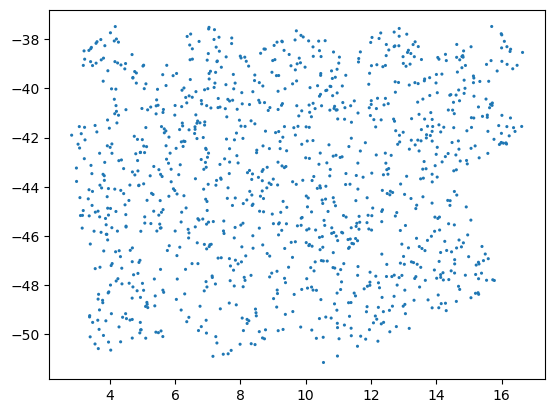

In [65]:
plt.scatter(specz['ra'], specz['dec'], s=5, ec='none');

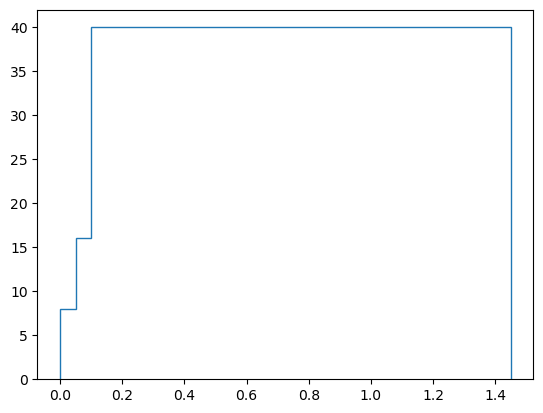

In [58]:
plt.hist(specz['z'], bins=np.arange(0,1.5,0.05), histtype='step');

## photometric sample

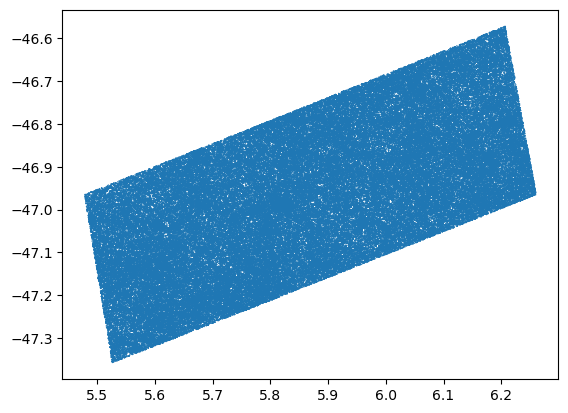

In [67]:
plt.scatter(phgal['ra'], phgal['dec'], s=1, ec='none');

In [69]:
phgal.columns.names

['id', 'ra', 'dec', 'refmag', 'refmag_err', 'mag', 'mag_err', 'ebv']

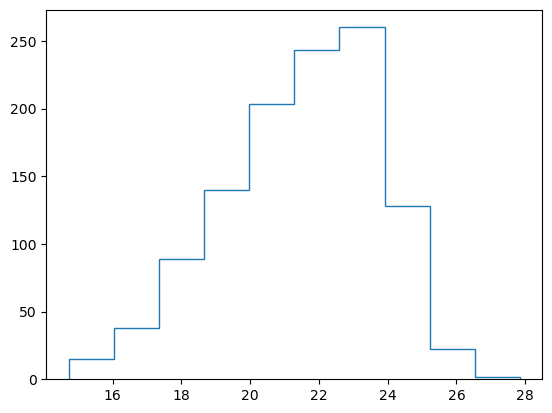

In [72]:
plt.hist(specz['refmag'], histtype='step');

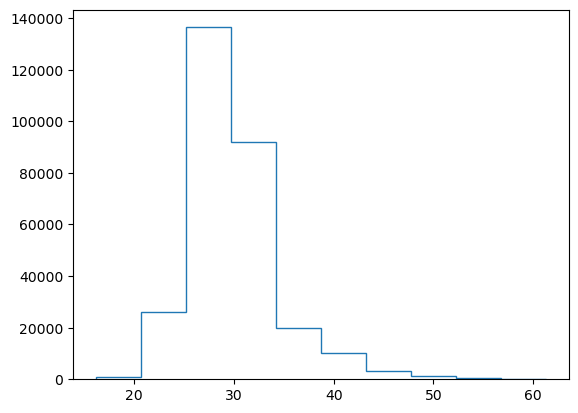

In [70]:
plt.hist(phgal['refmag'], histtype='step');

## geometry mask

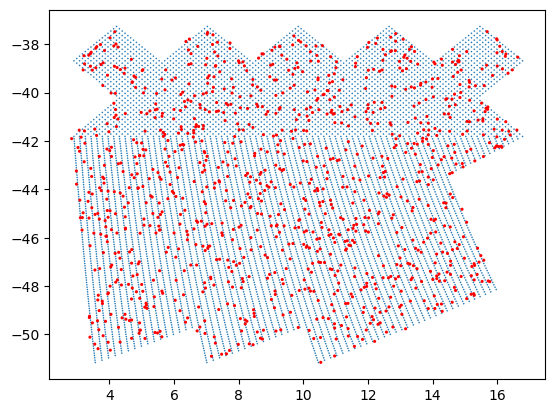

In [60]:
plt.scatter(*geoMask.upgrade(512).valid_pixels_pos(lonlat=True), s=1, ec='none', marker='D');
plt.scatter(specz['ra'], specz['dec'], s=5, c='r', ec='none');

## depth map

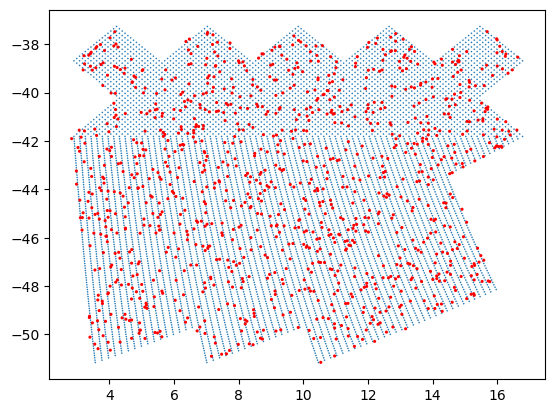

In [61]:
plt.scatter(*depthMap.upgrade(512).valid_pixels_pos(lonlat=True), s=1, ec='none', marker='D');
plt.scatter(specz['ra'], specz['dec'], s=5, c='r', ec='none');